<a href="https://colab.research.google.com/github/TK-Problem/random-experiments/blob/main/001_bayesian_linear_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from datetime import date, timedelta

## Configuration

Tickers, date range, lag, and split settings used throughout the experiment.

In [2]:
N_DAYS = 60   # Total trading days to keep
N_TEST = 5    # Most recent days reserved for testing

TARGET = "SPY"
PREDICTORS = [
    "QQQ",   # Nasdaq 100
    "IWM",   # Russell 2000 (small cap)
    "GLD",   # Gold
    "TLT",   # Long-term Treasuries
    "VIX",   # Volatility index (^VIX in yfinance)
    "XLE",   # Energy sector
    "XLF",   # Financials sector
    "EEM",   # Emerging markets
]

# Request ~1.5x calendar days to guarantee N_DAYS trading days after weekends/holidays
END_DATE = date.today().strftime("%Y-%m-%d")
START_DATE = (date.today() - timedelta(days=int(N_DAYS * 1.5))).strftime("%Y-%m-%d")
LAG = 1   # Days to lag predictors (1 = previous day)
RANDOM_SEED = 42

## Load Data

Download daily closing prices from Yahoo Finance and compute log returns.

In [3]:
print("Downloading price data from Yahoo Finance...")
tickers = [TARGET] + PREDICTORS
# ^VIX needs special handling
yf_tickers = [t if t != "VIX" else "^VIX" for t in tickers]

raw = yf.download(yf_tickers, start=START_DATE, end=END_DATE, auto_adjust=True)["Close"]

# Rename ^VIX back to VIX
raw.columns = [c.replace("^", "") for c in raw.columns]

# Compute daily log returns
returns = np.log(raw / raw.shift(1)).dropna()
print(f"Downloaded {len(returns)} trading days of data.\n")

[*********************100%***********************]  9 of 9 completed

Downloaded 59 trading days of data.



In [4]:
returns.head()

,EEM,GLD,IWM,QQQ,SPY,TLT,XLE,XLF,VIX
Date,,,,,,,,,
2025-12-12,-0.011730,0.005579,-0.015440,-0.019303,-0.010810,-0.009685,-0.009839,0.001457,0.058205
2025-12-15,-0.002954,0.000910,-0.007592,-0.005032,-0.001512,0.000687,-0.007056,0.000728,0.047155
2025-12-16,-0.006341,0.000227,-0.004743,0.001980,-0.002736,0.005477,-0.031014,-0.006385,-0.001213
2025-12-17,-0.007198,0.008552,-0.010701,-0.018711,-0.011065,-0.000911,0.021899,-0.000183,0.066887
2025-12-18,0.011342,-0.001805,0.005928,0.014386,0.007523,0.004772,-0.014622,-0.001649,-0.043498


## Feature Engineering

Lag predictor returns by `LAG` days so features only use information available before the target date.

In [5]:
# Target: SPY return on day t
y_series = returns[TARGET].copy()

# Features: each predictor's return on day t-LAG
X_df = returns[PREDICTORS].shift(LAG)

# Align and drop NaNs
df = pd.concat([y_series.rename("target"), X_df], axis=1).dropna()

y = df["target"].values
X_raw = df[PREDICTORS].values

print(f"Feature matrix shape: {X_raw.shape}")
print(f"Target vector shape:  {y.shape}\n")

Feature matrix shape: (58, 8)
Target vector shape:  (58,)



## Train / Test Split

Standardize features and split chronologically (no shuffle) to avoid look-ahead bias.

In [6]:
split_idx = len(y) - N_TEST
X_train_raw, X_test_raw = X_raw[:split_idx], X_raw[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test = df.index[split_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Train: {len(y_train)} days  |  Test: {len(y_test)} days ({dates_test[0].date()} – {dates_test[-1].date()})")

Train: 53 days  |  Test: 5 days (2026-03-04 – 2026-03-10)


## Bayesian Linear Regression Model

Define weakly informative priors and fit a PyMC Bayesian linear regression via NUTS sampling.

In [7]:
n_features = X_train.shape[1]

with pm.Model() as model:

    # --- Priors ---
    # Weakly informative priors — daily returns are small
    alpha  = pm.Normal("alpha", mu=0, sigma=0.01)            # intercept
    betas  = pm.Normal("betas", mu=0, sigma=0.05,            # coefficients
                        shape=n_features)
    sigma  = pm.HalfNormal("sigma", sigma=0.01)              # noise

    # --- Linear predictor ---
    mu = alpha + pm.math.dot(X_train, betas)

    # --- Likelihood ---
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train)

    # --- Sample posterior ---
    print("Sampling posterior (this may take a minute)...")
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        progressbar=True,
    )

print("\nSampling complete!")

Sampling posterior (this may take a minute)...


Output()


Sampling complete!


In [8]:
print("\n--- Posterior Summary ---")
summary = az.summary(trace, var_names=["alpha", "betas", "sigma"], round_to=6)
summary.index = (
    ["alpha"]
    + [f"beta_{p}" for p in PREDICTORS]
    + ["sigma"]
)
summary


--- Posterior Summary ---


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.000018,0.000986,-0.001887,0.001821,0.000010,0.000013,9767.921174,5660.577807,1.000940
beta_QQQ,-0.000386,0.002065,-0.004221,0.003642,0.000024,0.000023,7522.794577,5654.079155,1.000012
beta_IWM,0.001121,0.001685,-0.001946,0.004466,0.000019,0.000020,7747.527236,6067.367285,1.000041
beta_GLD,-0.001325,0.001213,-0.003530,0.000971,0.000013,0.000013,8336.877528,6026.545285,1.000192
beta_TLT,0.001829,0.001016,-0.000096,0.003748,0.000010,0.000013,11115.827171,6010.967522,1.001248
beta_VIX,0.002386,0.001842,-0.000885,0.006093,0.000020,0.000020,8745.904106,6793.606899,1.000470
beta_XLE,0.000409,0.001129,-0.001553,0.002701,0.000012,0.000013,9557.242514,6224.623223,1.000534
beta_XLF,-0.000402,0.001381,-0.003022,0.002163,0.000016,0.000015,7892.654477,6018.721170,1.000622
beta_EEM,0.001972,0.001557,-0.000949,0.004886,0.000016,0.000018,9190.933291,5990.865295,1.000185
sigma,0.007168,0.000780,0.005765,0.008632,0.000010,0.000010,6950.101984,5504.690171,1.000211


## In-Sample Diagnostics

Trace plots and forest plot to check sampler convergence and posterior coefficient estimates.

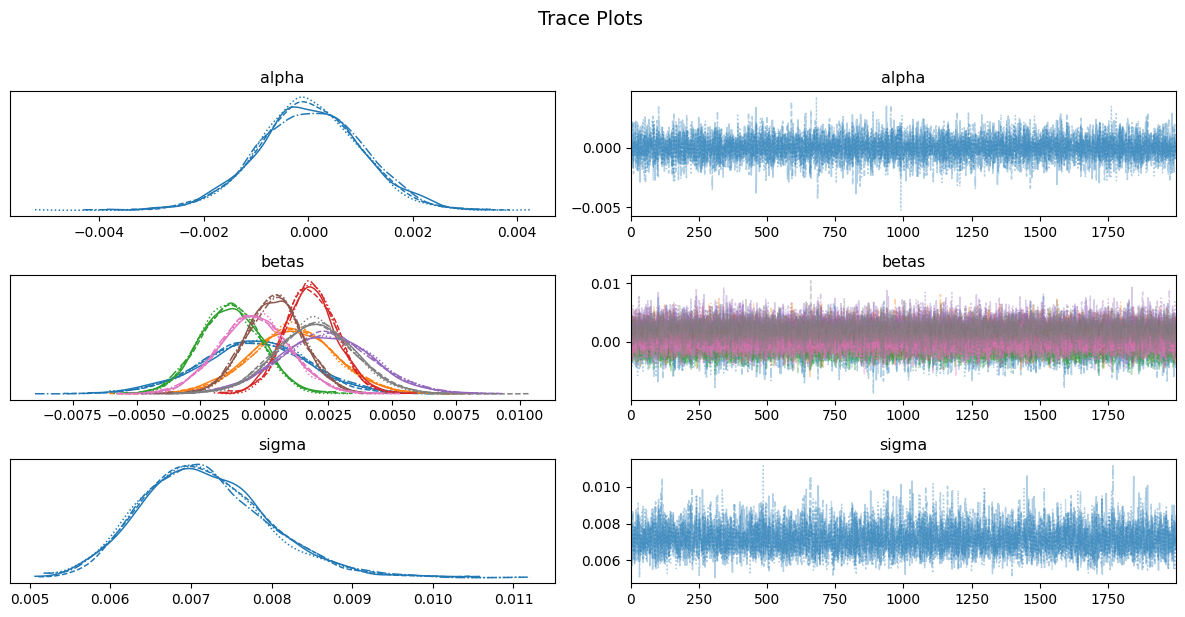

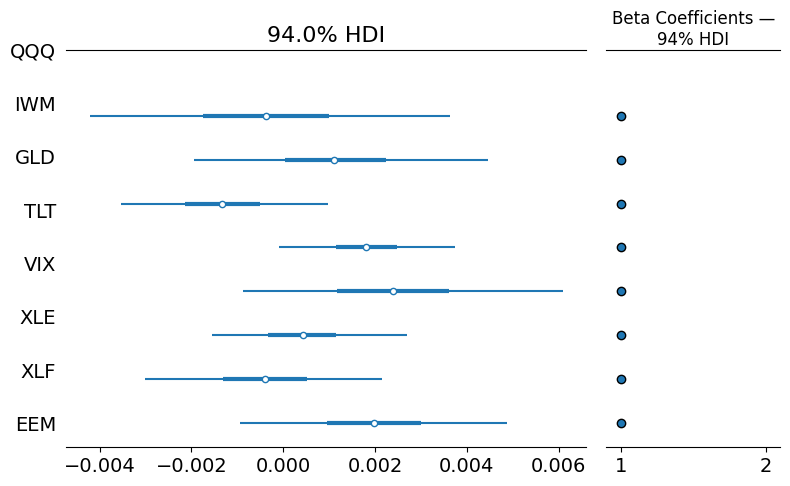

In [9]:
az.plot_trace(trace, var_names=["alpha", "betas", "sigma"], compact=True)
plt.suptitle("Trace Plots", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

az.plot_forest(trace, var_names=["betas"],
               combined=True, hdi_prob=0.94,
               r_hat=True)
plt.axvline(0, color="red", linestyle="--", alpha=0.6)
plt.yticks(ticks=range(n_features), labels=PREDICTORS[::-1])
plt.title("Beta Coefficients — 94% HDI")
plt.tight_layout()
plt.show()

## Out-of-Sample Prediction

Compute posterior predictive means and 94% HDI on the held-out test set, then report R², RMSE, and correlation.

In [10]:
with model:
  # no new data nodes — use posterior directly
    pm.set_data({})
    # Manually compute posterior predictive on test set
    post_alpha = trace.posterior["alpha"].values.flatten()        # (chains*draws,)
    post_betas = trace.posterior["betas"].values.reshape(-1, n_features)
    post_sigma = trace.posterior["sigma"].values.flatten()

    # Predicted mean for each posterior sample: (n_samples, n_test)
    mu_pred = post_alpha[:, None] + post_betas @ X_test.T

    y_pred_mean = mu_pred.mean(axis=0)
    y_pred_hdi  = az.hdi(mu_pred, hdi_prob=0.94)

# ---- Metrics ----
ss_res = np.sum((y_test - y_pred_mean) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2     = 1 - ss_res / ss_tot
rmse   = np.sqrt(np.mean((y_test - y_pred_mean) ** 2))
corr   = np.corrcoef(y_test, y_pred_mean)[0, 1]

print(f"\n--- Out-of-Sample Metrics ---")
print(f"  R²    : {r2:.4f}")
print(f"  RMSE  : {rmse:.6f}")
print(f"  Corr  : {corr:.4f}")


--- Out-of-Sample Metrics ---
  R²    : -0.0706
  RMSE  : 0.008395
  Corr  : 0.1684


/tmp/ipykernel_5356/2249292070.py:13: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  y_pred_hdi  = az.hdi(mu_pred, hdi_prob=0.94)


## Visualize Predictions

Plot actual vs. predicted SPY log returns and residuals over the test period.

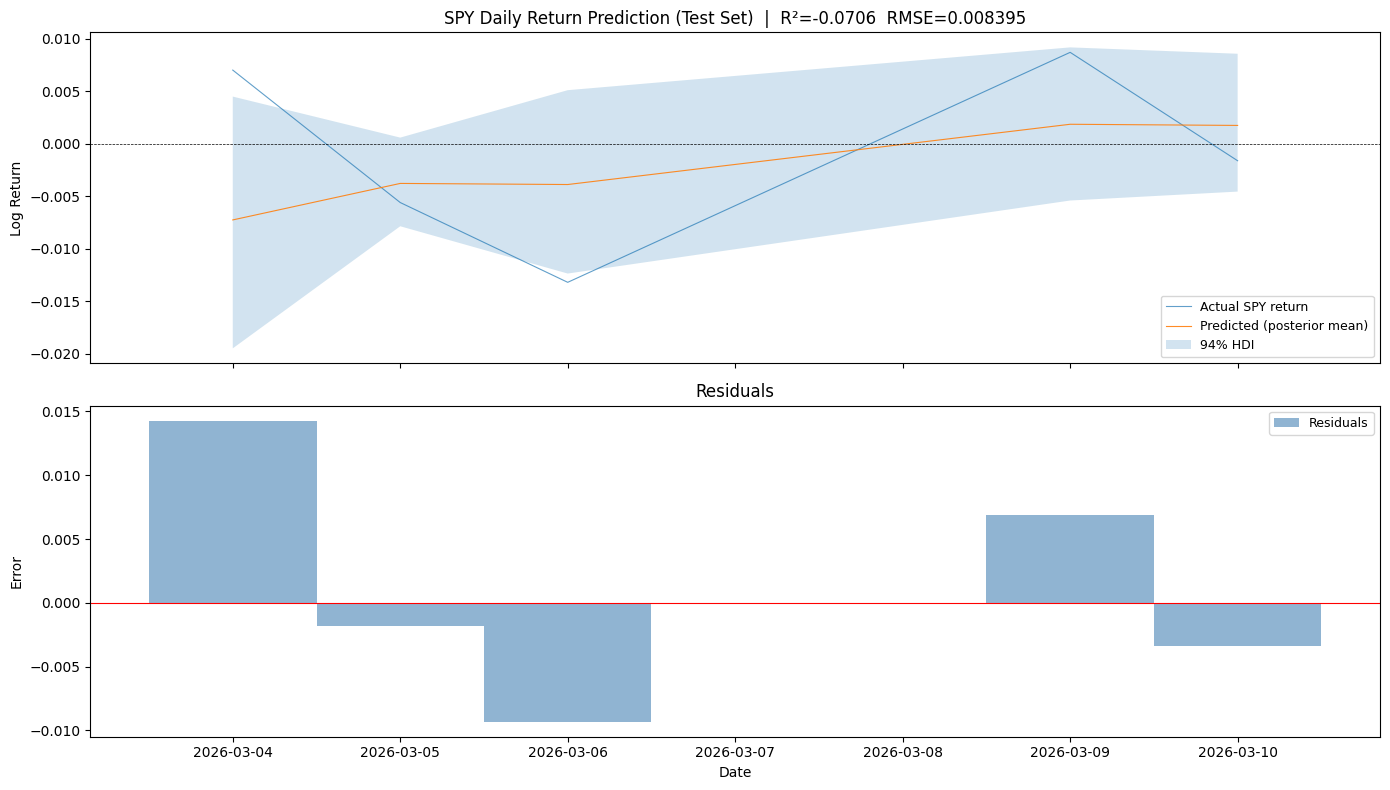

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(dates_test, y_test,       label="Actual SPY return",    alpha=0.7, linewidth=0.8)
axes[0].plot(dates_test, y_pred_mean,  label="Predicted (posterior mean)", alpha=0.9, linewidth=0.8)
axes[0].fill_between(dates_test,
                     y_pred_hdi[:, 0], y_pred_hdi[:, 1],
                     alpha=0.2, label="94% HDI")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_title(f"SPY Daily Return Prediction (Test Set)  |  R²={r2:.4f}  RMSE={rmse:.6f}")
axes[0].legend(fontsize=9)
axes[0].set_ylabel("Log Return")

residuals = y_test - y_pred_mean
axes[1].bar(dates_test, residuals, width=1, alpha=0.6, color="steelblue", label="Residuals")
axes[1].axhline(0, color="red", linewidth=0.8)
axes[1].set_title("Residuals")
axes[1].set_ylabel("Error")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Coefficient Importance

Rank predictors by the Bayesian signal-to-noise ratio (|mean| / std) and plot posterior beta estimates.


--- Coefficient Summary (sorted by |mean/std|) ---
ETF  beta_mean  beta_std   signal
TLT   0.001829  0.001016 1.800300
VIX   0.002386  0.001842 1.295339
EEM   0.001972  0.001557 1.266310
GLD  -0.001325  0.001213 1.092727
IWM   0.001121  0.001685 0.665244
XLE   0.000409  0.001129 0.362164
XLF  -0.000402  0.001381 0.291297
QQQ  -0.000386  0.002065 0.186825


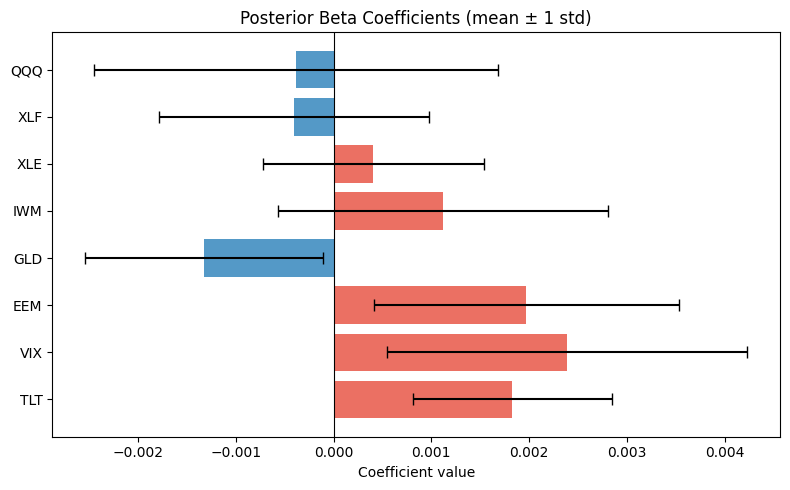

In [12]:
beta_means = post_betas.mean(axis=0)
beta_stds  = post_betas.std(axis=0)

coef_df = pd.DataFrame({
    "ETF":        PREDICTORS,
    "beta_mean":  beta_means,
    "beta_std":   beta_stds,
    "signal":     np.abs(beta_means) / beta_stds,   # Bayes analog of t-stat
}).sort_values("signal", ascending=False)

print("\n--- Coefficient Summary (sorted by |mean/std|) ---")
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if v > 0 else "#2980b9" for v in coef_df["beta_mean"]]
ax.barh(coef_df["ETF"], coef_df["beta_mean"], xerr=coef_df["beta_std"],
        color=colors, capsize=4, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Posterior Beta Coefficients (mean ± 1 std)")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.show()